In [11]:
from datasets import load_dataset, concatenate_datasets, DatasetDict

arabic_dataset = load_dataset(
    "parquet",
    data_files={
        "train": "hf://datasets/csebuetnlp/xlsum@~parquet/arabic/train/*.parquet",
        "validation": "hf://datasets/csebuetnlp/xlsum@~parquet/arabic/validation/*.parquet",
        "test": "hf://datasets/csebuetnlp/xlsum@~parquet/arabic/test/*.parquet"
    }
)

english_dataset = load_dataset(
    "parquet",
    data_files={
        "train": "hf://datasets/csebuetnlp/xlsum@~parquet/english/train/*.parquet",
        "validation": "hf://datasets/csebuetnlp/xlsum@~parquet/english/validation/*.parquet",
        "test": "hf://datasets/csebuetnlp/xlsum@~parquet/english/test/*.parquet"
    }
)



In [12]:
print(arabic_dataset)
print(english_dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'url', 'title', 'summary', 'text'],
        num_rows: 37519
    })
    validation: Dataset({
        features: ['id', 'url', 'title', 'summary', 'text'],
        num_rows: 4689
    })
    test: Dataset({
        features: ['id', 'url', 'title', 'summary', 'text'],
        num_rows: 4689
    })
})
DatasetDict({
    train: Dataset({
        features: ['id', 'url', 'title', 'summary', 'text'],
        num_rows: 306522
    })
    validation: Dataset({
        features: ['id', 'url', 'title', 'summary', 'text'],
        num_rows: 11535
    })
    test: Dataset({
        features: ['id', 'url', 'title', 'summary', 'text'],
        num_rows: 11535
    })
})


In [13]:
def show_sample(dataset, num_sample=3,seed=42):
    sample = dataset["train"].shuffle(seed=seed).select(range(num_sample))
    for row in sample:
        print(f'title : {row["title"]}')
        print(f'summary : {row["summary"]}')
        print(f'text : {row["text"]}')
        print("-"*50)


In [14]:
show_sample(arabic_dataset)
show_sample(english_dataset)



title : مناوشات متفرقة بين شبان فلسطينيين والجيش الإسرائيلي في القدس الشرقية
summary : شهدت مدينة القدس مناوشات متفرقة بين الجيش الإسرائيلي وشبان فلسطينيين في مناطق باب العامود وسلوان ورأس العامود في القدس الشرقية.
text : نشرت الشرطة الإسرائيلية أكثر من خمسة آلاف من حرس الحدود في أحياء القدس الشرقية. وتقول مراسلة بي بي سي في القدس،نوال أسعد، إن شابا فلسطينيا في منطقة الطور أصيب برصاصة مطاطية في الرأس نقل على اثرها للمستشفى. كما اندلعت مواجهات عند حاجز قلنديا العسكري في مظاهرة قامت الشرطة بتفريقها باستخدام الغاز المسيل للدموع والرصاص المطاطي. وأضافت مراسلتنا أن متظاهرا ألقى قنبلة حارقة على الشرطة الإسرائيلية في منطقة باب العامود. وقد نشرت الشرطة أكثر من خمسة آلاف من حرس الحدود في أحياء المدينة وقالت إن هذا الانتشار سيستمر حتى شهر أكتوبر/تشرين الأول المقبل الذي يصادف أيضا نهاية الأعياد اليهودية. مواضيع قد تهمك نهاية وكان رئيس الوزراء الإسرائيلي ووزير الامن الداخلي أعلنا خطة لنشر من ٧٠٠ إلى ٩٠٠ من حرس الحدود في تسعة احياء في القدس الشرقية حتى الشهر المقبل. وتدرس لجنة الأمن التابعة للكنيست

In [15]:
df = arabic_dataset["train"].to_pandas()
df["text_word_count"] = df["text"].apply(lambda x: len(str(x).split()))
df["summary_word_count"] = df["summary"].apply(lambda x: len(str(x).split()))

max_text_len = df["text_word_count"].quantile(0.99)
max_summary_len = df["summary_word_count"].quantile(0.99)

df["text_word_count"] = df[df["text_word_count"] <= max_text_len]["text_word_count"]
df["summary_word_count"] = df[df["summary_word_count"] <= max_summary_len]["summary_word_count"]


In [16]:
print(df["text_word_count"].describe())
print(df["summary_word_count"].describe())



count    37143.000000
mean       412.127400
std        308.019035
min         22.000000
25%        204.000000
50%        311.000000
75%        517.000000
max       1709.000000
Name: text_word_count, dtype: float64
count    37160.000000
mean        25.136868
std          8.389300
min          1.000000
25%         19.000000
50%         24.000000
75%         30.000000
max         57.000000
Name: summary_word_count, dtype: float64


In [17]:
print(df[df["summary_word_count"] <= 4][["text", "summary"]].head(10))

                                                    text  \
1272   اختتم قادة الدول العشرين اجتماعا عبر الفيديو ت...   
3609   الأطباء في أستراليا يريدون مواجهة المحرمات بشأ...   
4186   يرى بعض أهالي بورسعيد أن مؤامرة حيكت ضدهم هكذا...   
5249   تشهد الكويت حملة إلكترونية على مواقع التواصل ا...   
5506   عاد الجدل حول قطع الطرقات في لبنان إلى الواجهة...   
37446  بي بي سي يعصف التضخم بالاقتصاد الفنزويلي أدى ا...   
37448  اجتاح إعصاران منطقة غربي اليابان لكن بدون احدا...   
37449  رئيس الورزار العراقي مصطفى الكاظمي في مواجهة م...   
37450  يختلط الشعور لدى زائر هوليوود للمرة الأولى. فه...   
37451  السودان وإسرائيل إعلان للتطبيع بعد نفي سوداني ...   

                                       summary  
1272              #مجموعه_العشرين_في_السعودي ة  
3609   "الرياضيات، والعلوم، والتاريخ، والموت".  
4186           "عملتوها يا مصريين.. عملتوها!!"  
5249              #من_حقي_ أ شتري_بيت_ بالكويت  
5506                # حسين_شلهوب و#سناء_الجندي  
37446                     فريق الصحافة المصور

In [18]:
print(len(df))
df = df[df["summary_word_count"] > 4].reset_index(drop=True)
print(len(df))

37519
37095


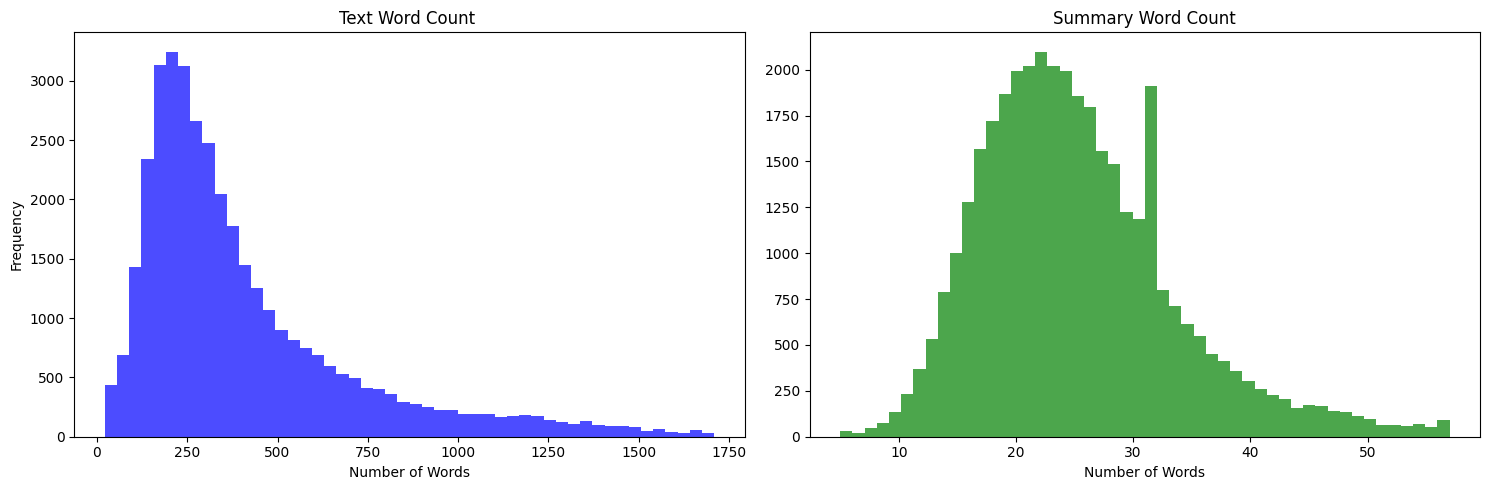

In [19]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df["text_word_count"], bins=50, color='blue', alpha=0.7)
axes[0].set_title("Text Word Count ")
axes[0].set_xlabel("Number of Words")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["summary_word_count"], bins=50, color='green', alpha=0.7)
axes[1].set_title("Summary Word Count")
axes[1].set_xlabel("Number of Words")

plt.tight_layout()
plt.show()

In [20]:
df2 = english_dataset["train"].to_pandas()
df2["text_word_count"] = df2["text"].apply(lambda x: len(str(x).split()))
df2["summary_word_count"] = df2["summary"].apply(lambda x: len(str(x).split()))


In [21]:
print(df2["text_word_count"].describe())
print(df2["summary_word_count"].describe())



count    306522.000000
mean        462.041338
std         357.486541
min           7.000000
25%         241.000000
50%         367.000000
75%         606.000000
max       39282.000000
Name: text_word_count, dtype: float64
count    306522.000000
mean         22.132405
std           7.303130
min           1.000000
25%          18.000000
50%          21.000000
75%          25.000000
max         172.000000
Name: summary_word_count, dtype: float64


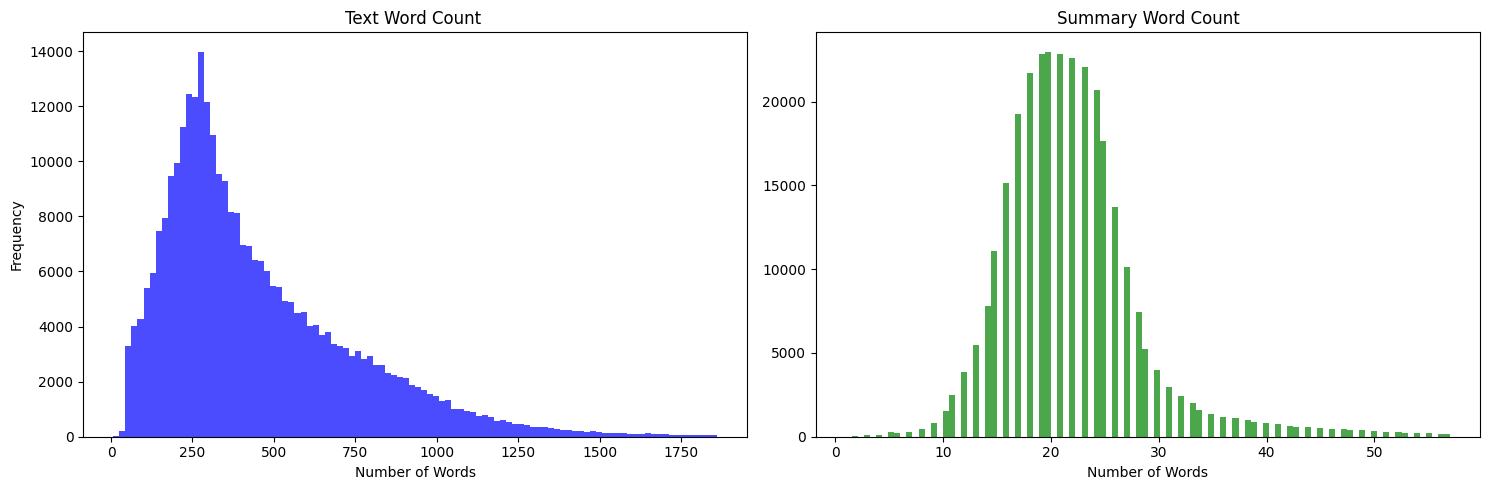

In [22]:


max_text_len = df2["text_word_count"].quantile(0.995)
max_summary_len = df2["summary_word_count"].quantile(0.995)

df2["text_word_count"] = df2[df2["text_word_count"] <= max_text_len]["text_word_count"]
df2["summary_word_count"] = df2[df2["summary_word_count"] <= max_summary_len]["summary_word_count"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df2["text_word_count"], bins=100, color='blue', alpha=0.7)
axes[0].set_title("Text Word Count ")
axes[0].set_xlabel("Number of Words")
axes[0].set_ylabel("Frequency")

axes[1].hist(df2["summary_word_count"], bins=100, color='green', alpha=0.7)
axes[1].set_title("Summary Word Count")
axes[1].set_xlabel("Number of Words")

plt.tight_layout()
plt.show()

In [23]:
print(df2["text_word_count"].describe())
print(df2["summary_word_count"].describe())



count    304989.000000
mean        450.409523
std         293.507480
min           7.000000
25%         240.000000
50%         365.000000
75%         601.000000
max        1861.000000
Name: text_word_count, dtype: float64
count    305030.000000
mean         21.904127
std           6.495416
min           1.000000
25%          18.000000
50%          21.000000
75%          25.000000
max          57.000000
Name: summary_word_count, dtype: float64


In [24]:
print(df2[df2["summary_word_count"] <= 6][["text", "summary"]].head(10))

                                                   text  \
44    Patrick BurnsPolitical editor, Midlands This w...   
237   By Chris PageBBC News NI Political Corresponde...   
438   By Jonathan AmosBBC Science Correspondent, New...   
600   The UK has had its hottest July day on record,...   
693   David CornockParliamentary correspondent, Wale...   
1518  Laura KuenssbergPolitical editor@bbclaurakon T...   
1578  By Hugh SchofieldBBC News, Paris Winning the W...   
1909  Soutik BiswasDelhi correspondent Serving up so...   
2102  Laura KuenssbergPolitical editor@bbclaurakon T...   
2374  Laura KuenssbergPolitical editor@bbclaurakon T...   

                                              summary  
44        "Europe: journey to an unknown destination"  
237         Some council functions don't ever change.  
438               Britain has a new tallest mountain.  
600                    Are you feelin' hot, hot, hot?  
693            Was Owain Glyndwr's parliament a myth?  
1518  Accelera

In [25]:
df2 = df2[df2["summary_word_count"] > 4].reset_index(drop=True)


In [26]:
print(len(df2))

304775


In [27]:
from datasets import DatasetDict, concatenate_datasets, Dataset

df = Dataset.from_pandas(df)
df2 = Dataset.from_pandas(df2)

bilingual_dataset = DatasetDict()

bilingual_dataset["train"] = concatenate_datasets(
    [df, df2] 
).shuffle(seed=42)

bilingual_dataset["validation"] = concatenate_datasets(
    [arabic_dataset["validation"], english_dataset["validation"]] 
).shuffle(seed=42)

# 3. دمج بيانات الاختبار (من الداتا الأصلية)
bilingual_dataset["test"] = concatenate_datasets(
    [arabic_dataset["test"], english_dataset["test"]]
).shuffle(seed=42)

print(bilingual_dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'url', 'title', 'summary', 'text', 'text_word_count', 'summary_word_count'],
        num_rows: 341870
    })
    validation: Dataset({
        features: ['id', 'url', 'title', 'summary', 'text'],
        num_rows: 16224
    })
    test: Dataset({
        features: ['id', 'url', 'title', 'summary', 'text'],
        num_rows: 16224
    })
})


In [28]:
from transformers import AutoTokenizer

model_checkpoint = "google/mt5-small"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

In [29]:
tokenizer.model_max_length

1000000000000000019884624838656

In [36]:
inputs = tokenizer(["I loved reading the Hunger Games!"])
inputs

{'input_ids': [[336, 259, 28387, 11807, 287, 62893, 295, 12507, 309, 1]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}

In [41]:
tokenizer.convert_ids_to_tokens(inputs.input_ids[0])

['▁I', '▁', 'loved', '▁reading', '▁the', '▁Hung', 'er', '▁Games', '!', '</s>']

In [32]:
max_input_length = 512
max_target_length = 64


def preprocess_function(examples):
    model_inputs = tokenizer(
        examples["text"],
        max_length=max_input_length,
        truncation=True,
    )
    labels = tokenizer(
        examples["summary"], max_length=max_target_length, truncation=True
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [33]:
tokenized_datasets = bilingual_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/341870 [00:00<?, ? examples/s]

In [42]:
import evaluate

rouge_score = evaluate.load("rouge")

In [59]:
import re
def bilingual_tokenizer(text):
    return re.findall(r'\w+', text)

generated_summary = "أعلنت الحكومة عن افتتاح مستشفى كبير جدا في العاصمة عمان"
reference_summary = "افتتاح مستشفى جديد في العاصمة عمان"

scores = rouge_score.compute(
    predictions=[generated_summary], 
    references=[reference_summary],
    tokenizer=bilingual_tokenizer  
)

print(scores)

{'rouge1': np.float64(0.625), 'rouge2': np.float64(0.42857142857142855), 'rougeL': np.float64(0.625), 'rougeLsum': np.float64(0.625)}


In [48]:
import nltk

nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\khale\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [50]:
from nltk.tokenize import sent_tokenize

def three_sentence_summary(text):
    return "\n".join(sent_tokenize(text)[:3])


print(three_sentence_summary(bilingual_dataset["train"][1]["text"]))

Vicky Balch, from Lancashire, had her right leg amputated below the knee following seven rounds of surgery.
She was injured when the theme park's Smiler ride crashed into an empty carriage in front of it on 2 June.
Days after the crash, it emerged that Leah Washington, 17, had to have a leg amputated above the knee.


In [51]:
def evaluate_baseline(dataset, metric):
    summaries = [three_sentence_summary(text) for text in dataset["text"]]
    return metric.compute(predictions=summaries, references=dataset["summary"])

In [ ]:

score = evaluate_baseline(bilingual_dataset["validation"], rouge_score)

rouge_names = ["rouge1", "rouge2", "rougeL", "rougeLsum"]

rouge_dict = dict((rn, round(score[rn] * 100, 2)) for rn in rouge_names)

print(rouge_dict)

{'rouge1': np.float64(14.07), 'rouge2': np.float64(1.93), 'rougeL': np.float64(9.44), 'rougeLsum': np.float64(11.17)}


In [54]:
from transformers import AutoModelForSeq2SeqLM

model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [56]:
from huggingface_hub import notebook_login

notebook_login()

In [88]:
from transformers import Seq2SeqTrainingArguments

batch_size = 8
num_train_epochs = 8
logging_steps = len(tokenized_datasets["train"]) // batch_size
model_name = model_checkpoint.split("/")[-1]

args = Seq2SeqTrainingArguments(
    output_dir=f"{model_name}-finetuned-amazon-en-es",
    eval_strategy="epoch",
    learning_rate=5.6e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=num_train_epochs,
    predict_with_generate=True,
    logging_steps=logging_steps,
    fp16=True,
    push_to_hub=True,
)

In [77]:
import numpy as np
import re 

def bilingual_tokenizer(text):
    return re.findall(r'\w+', text)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    
    decoded_preds = ["\n".join(sent_tokenize(pred.strip())) for pred in decoded_preds]
    decoded_labels = ["\n".join(sent_tokenize(label.strip())) for label in decoded_labels]
    
    result = rouge_score.compute(
        predictions=decoded_preds, 
        references=decoded_labels, 
        use_stemmer=False,   
        tokenizer=bilingual_tokenizer 
    )
    
    result = {key: value * 100 for key, value in result.items()}
    
    return {k: round(v, 4) for k, v in result.items()}

In [78]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

In [79]:
print(tokenized_datasets["train"])
bilingual_dataset["train"]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 341870
})


Dataset({
    features: ['id', 'url', 'title', 'summary', 'text', 'text_word_count', 'summary_word_count'],
    num_rows: 341870
})

In [80]:
columns_to_keep = ['input_ids', 'attention_mask', 'labels']

for split in tokenized_datasets.keys():
    columns_to_remove = [col for col in tokenized_datasets[split].column_names if col not in columns_to_keep]
    
    tokenized_datasets[split] = tokenized_datasets[split].remove_columns(columns_to_remove)

print(tokenized_datasets)

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 341870
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 16224
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 16224
    })
})


In [91]:

small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(20000))
small_eval_dataset = tokenized_datasets["validation"].shuffle(seed=42).select(range(2000))
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    model,
    args,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

In [82]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel,Rougelsum
No log,16.891985,0,3.100600,0.321100,2.906300,2.906700


{'eval_loss': 16.891984939575195,
 'eval_rouge1': 3.1006,
 'eval_rouge2': 0.3211,
 'eval_rougeL': 2.9063,
 'eval_rougeLsum': 2.9067}

In [92]:
trainer.train()

Epoch,Training Loss,Validation Loss


OutOfMemoryError: CUDA out of memory. Tried to allocate 490.00 MiB. GPU 0 has a total capacity of 4.00 GiB of which 0 bytes is free. Of the allocated memory 7.37 GiB is allocated by PyTorch, and 2.80 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
trainer.evaluate()